In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 26})
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 

from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au

In [4]:
data_1 = np.concatenate((np.loadtxt('all_harmonics_output.txt'), 
                     np.loadtxt('2025_11_22_injections.txt'),
                     np.loadtxt('2025_11_28_injections.txt')))
print(f'Number of pointings: {len(np.unique(data_1[:, 0:2], axis=0))}')
#print(f'Number of days: {len(np.unique(data_1[:, 2]))}')
print(f'Total fraction of recovered injections: {(100*len(data_1[data_1[:, -1] > 0.])/len(data_1)):.2f}%')
print(f'Number of injections: {len(data_1)}')
RA = data_1[:, 0]
Dec = data_1[:, 1]
f = data_1[:, 4]
DM = data_1[:, 5]
S = data_1[:, 6]
TPA_idx = data_1[:, 3].astype('int')
fwhm_array = np.load('../profiles/TPA_fwhm.npy')
fwhm = fwhm_array[TPA_idx]
data_1[:, 7] = fwhm

Number of pointings: 15129
Total fraction of recovered injections: 30.53%
Number of injections: 271967


In [5]:
RA_bins = np.arange(min(RA), max(RA), 0.5)
Dec_bins = np.arange(min(Dec), max(Dec), 0.5)
f_bins = np.logspace(np.log10(min(f)), np.log10(max(f)), 1000)
DM_bins = np.arange(min(DM), 1000)
S_bins = np.logspace(np.log10(min(S)), np.log10(max(S)), 1000)
fwhm_bins = np.logspace(np.log10(min(fwhm)), np.log10(0.15), 1000)

In [6]:
f_dev = 100
DM_dev = 100
S_dev = 100
FWHM_dev = 80

All data_1:

In [7]:
dm_f_inj_p_smooth_1, dm_f_ret_p_1, dm_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1,
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

dm_s_inj_p_smooth_1, dm_s_ret_p_1, dm_s_ret_p_smooth_1 = au.get_sensitivity(
    data_1,
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

s_f_inj_p_smooth_1, s_f_ret_p_1, s_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1,
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

s_fwhm_inj_p_smooth_1, s_fwhm_ret_p_1, s_fwhm_ret_p_smooth_1 = au.get_sensitivity(
    data_1,
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

dm_fwhm_inj_p_smooth_1, dm_fwhm_ret_p_1, dm_fwhm_ret_p_smooth_1 = au.get_sensitivity(
    data_1,
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

fwhm_f_inj_p_smooth_1, fwhm_f_ret_p_1, fwhm_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1,
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:34: RuntimeWarning: invalid value encountered in divide
  arr_ret_p = arr_retrieved / arr_injected


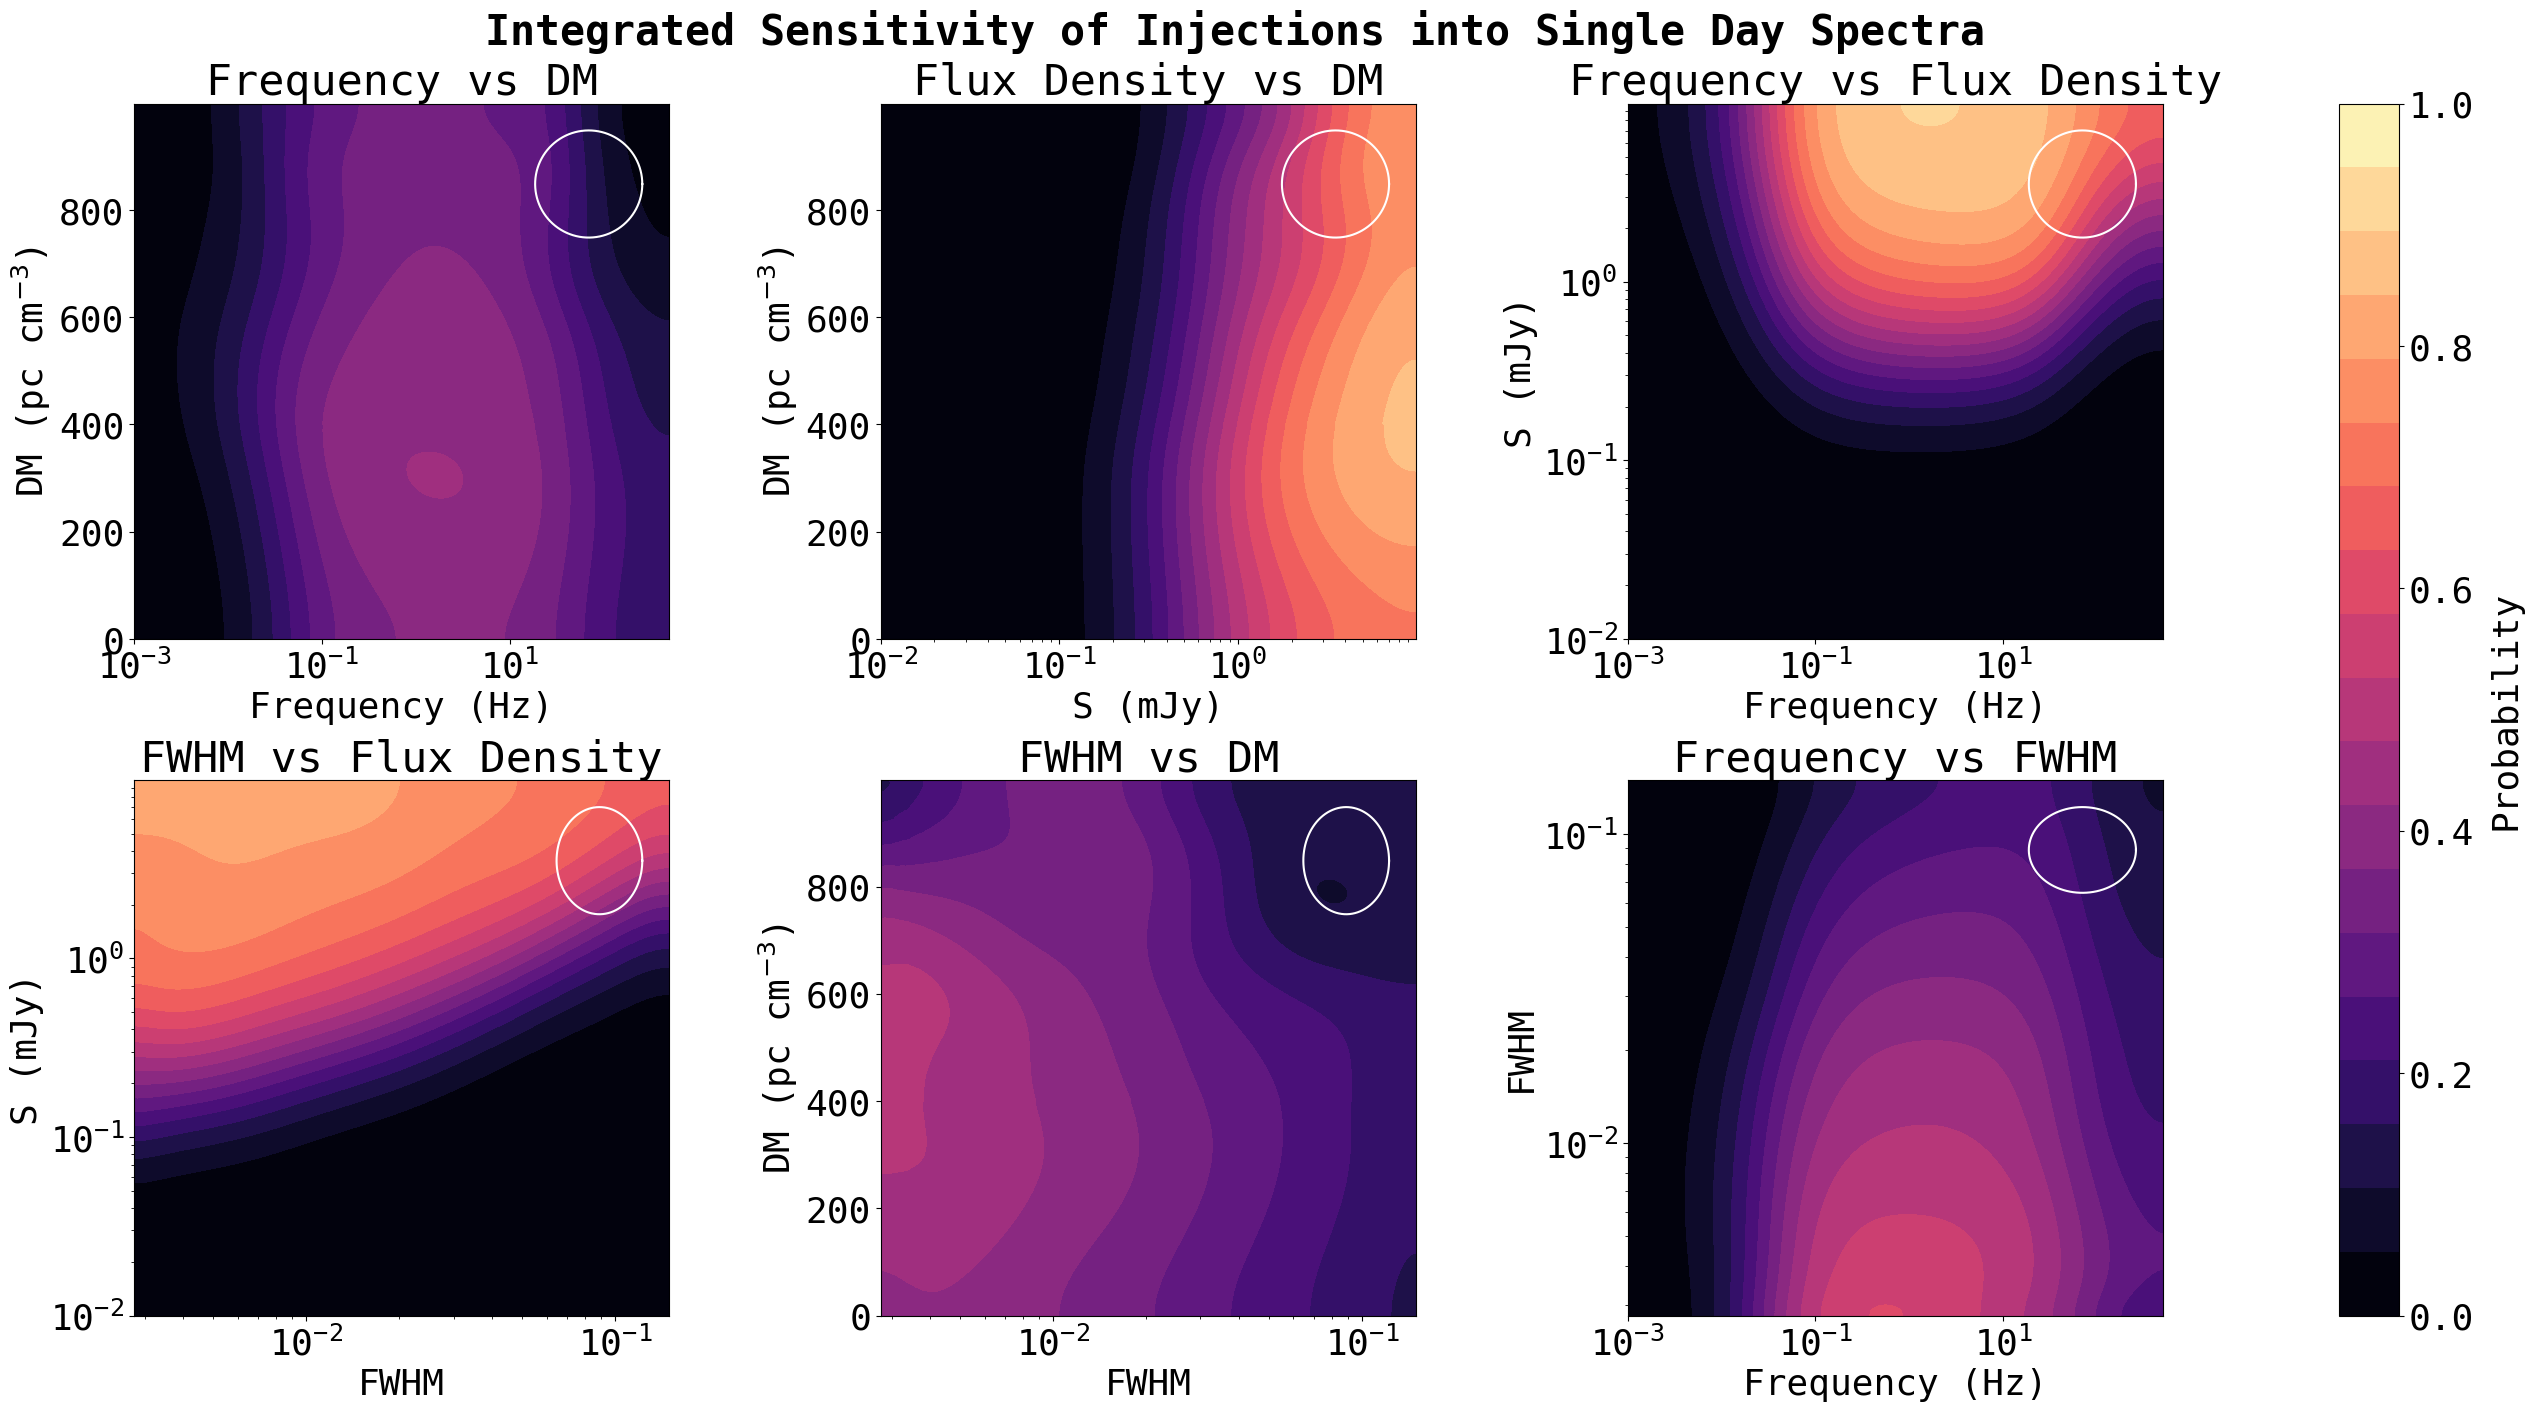

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(26, 14), layout = 'constrained')
ax = ax.flatten()
import importlib
importlib.reload(au)

#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_ret_p_smooth_1, 
                           levels=au.make_levels(dm_f_ret_p_smooth_1),cmap='magma')
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
#ax[0].set_xlim(1e-2, max(f_bins))
#ax[0].set_ylim(0, 700)
ax[0].set_box_aspect(1)
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_ret_p_smooth_1, 
                           levels=au.make_levels(dm_s_ret_p_smooth_1), cmap='magma')
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
#ax[1].set_xlim(1e-1, max(S_bins) - 1)
#ax[1].set_ylim(0, 700)
ax[1].set_box_aspect(1)
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = ax[2].contourf(f_bins[:-1], S_bins[:-1], s_f_ret_p_smooth_1, 
                           levels=au.make_levels(s_f_ret_p_smooth_1), cmap='magma')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('S (mJy)')
ax[2].set_title('Frequency vs Flux Density')
ax[2].set_box_aspect(1)
#ax[2].set_xlim(1e-2, max(f_bins))
#ax[2].set_ylim(1e-1, max(S_bins) - 1)
au.add_ellipse(ax[2], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = ax[3].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_ret_p_smooth_1, 
                           levels=au.make_levels(s_fwhm_ret_p_smooth_1), cmap='magma')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('FWHM vs Flux Density')
ax[3].set_box_aspect(1)
#ax[3].set_ylim(5e-2, max(S_bins) -1 )
au.add_ellipse(ax[3], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = ax[4].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_ret_p_smooth_1, 
                           levels=au.make_levels(dm_fwhm_ret_p_smooth_1), cmap='magma')
ax[4].set_xscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[4].set_title('FWHM vs DM')
#ax[4].set_ylim(0, 700)
ax[4].set_xlim(fwhm_bins[0], fwhm_bins[-2])
ax[4].set_box_aspect(1)
au.add_ellipse(ax[4], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = ax[5].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_ret_p_smooth_1, 
                           levels=au.make_levels(fwhm_f_ret_p_smooth_1), cmap='magma')
ax[5].set_xscale('log')
ax[5].set_yscale('log')
ax[5].set_xlabel('Frequency (Hz)')
ax[5].set_ylabel('FWHM')
ax[5].set_title('Frequency vs FWHM')
ax[5].set_box_aspect(1)
ax[5].set_ylim(fwhm_bins[0], fwhm_bins[-2])
#ax[5].set_xlim(1e-2, max(f_bins))
au.add_ellipse(ax[5], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

cbar = fig.colorbar(cf5, ax=ax, location='right', pad=0.08)
cbar.set_label('Probability', labelpad=10)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.suptitle('Integrated Sensitivity of Injections into Single Day Spectra', 
             fontsize=30, fontweight='bold')
plt.show()

In [9]:
S_mask = data_1[:, 6] < 0.1
retrieved_mask = data_1[:, -1] > 0
data_1_low_flux = data_1[S_mask]
data_1_low_flux_retrieved = data_1[S_mask & retrieved_mask]
100*len(data_1_low_flux_retrieved) / len(data_1_low_flux)

0.0914933499955369

In [10]:
sigma_mask = data_1[:, 8] > 6.

dm_f_inj_p_smooth_1, _, dm_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

dm_s_inj_p_smooth_1, _, dm_s_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

s_f_inj_p_smooth_1, _, s_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

s_fwhm_inj_p_smooth_1, _, s_fwhm_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

dm_fwhm_inj_p_smooth_1, _, dm_fwhm_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

fwhm_f_inj_p_smooth_1, _, fwhm_f_ret_p_smooth_1 = au.get_sensitivity(
    data_1[sigma_mask],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:32: RuntimeWarning: invalid value encountered in divide
  arr_ret_p_smooth = arr_ret_smooth / arr_inj_smooth


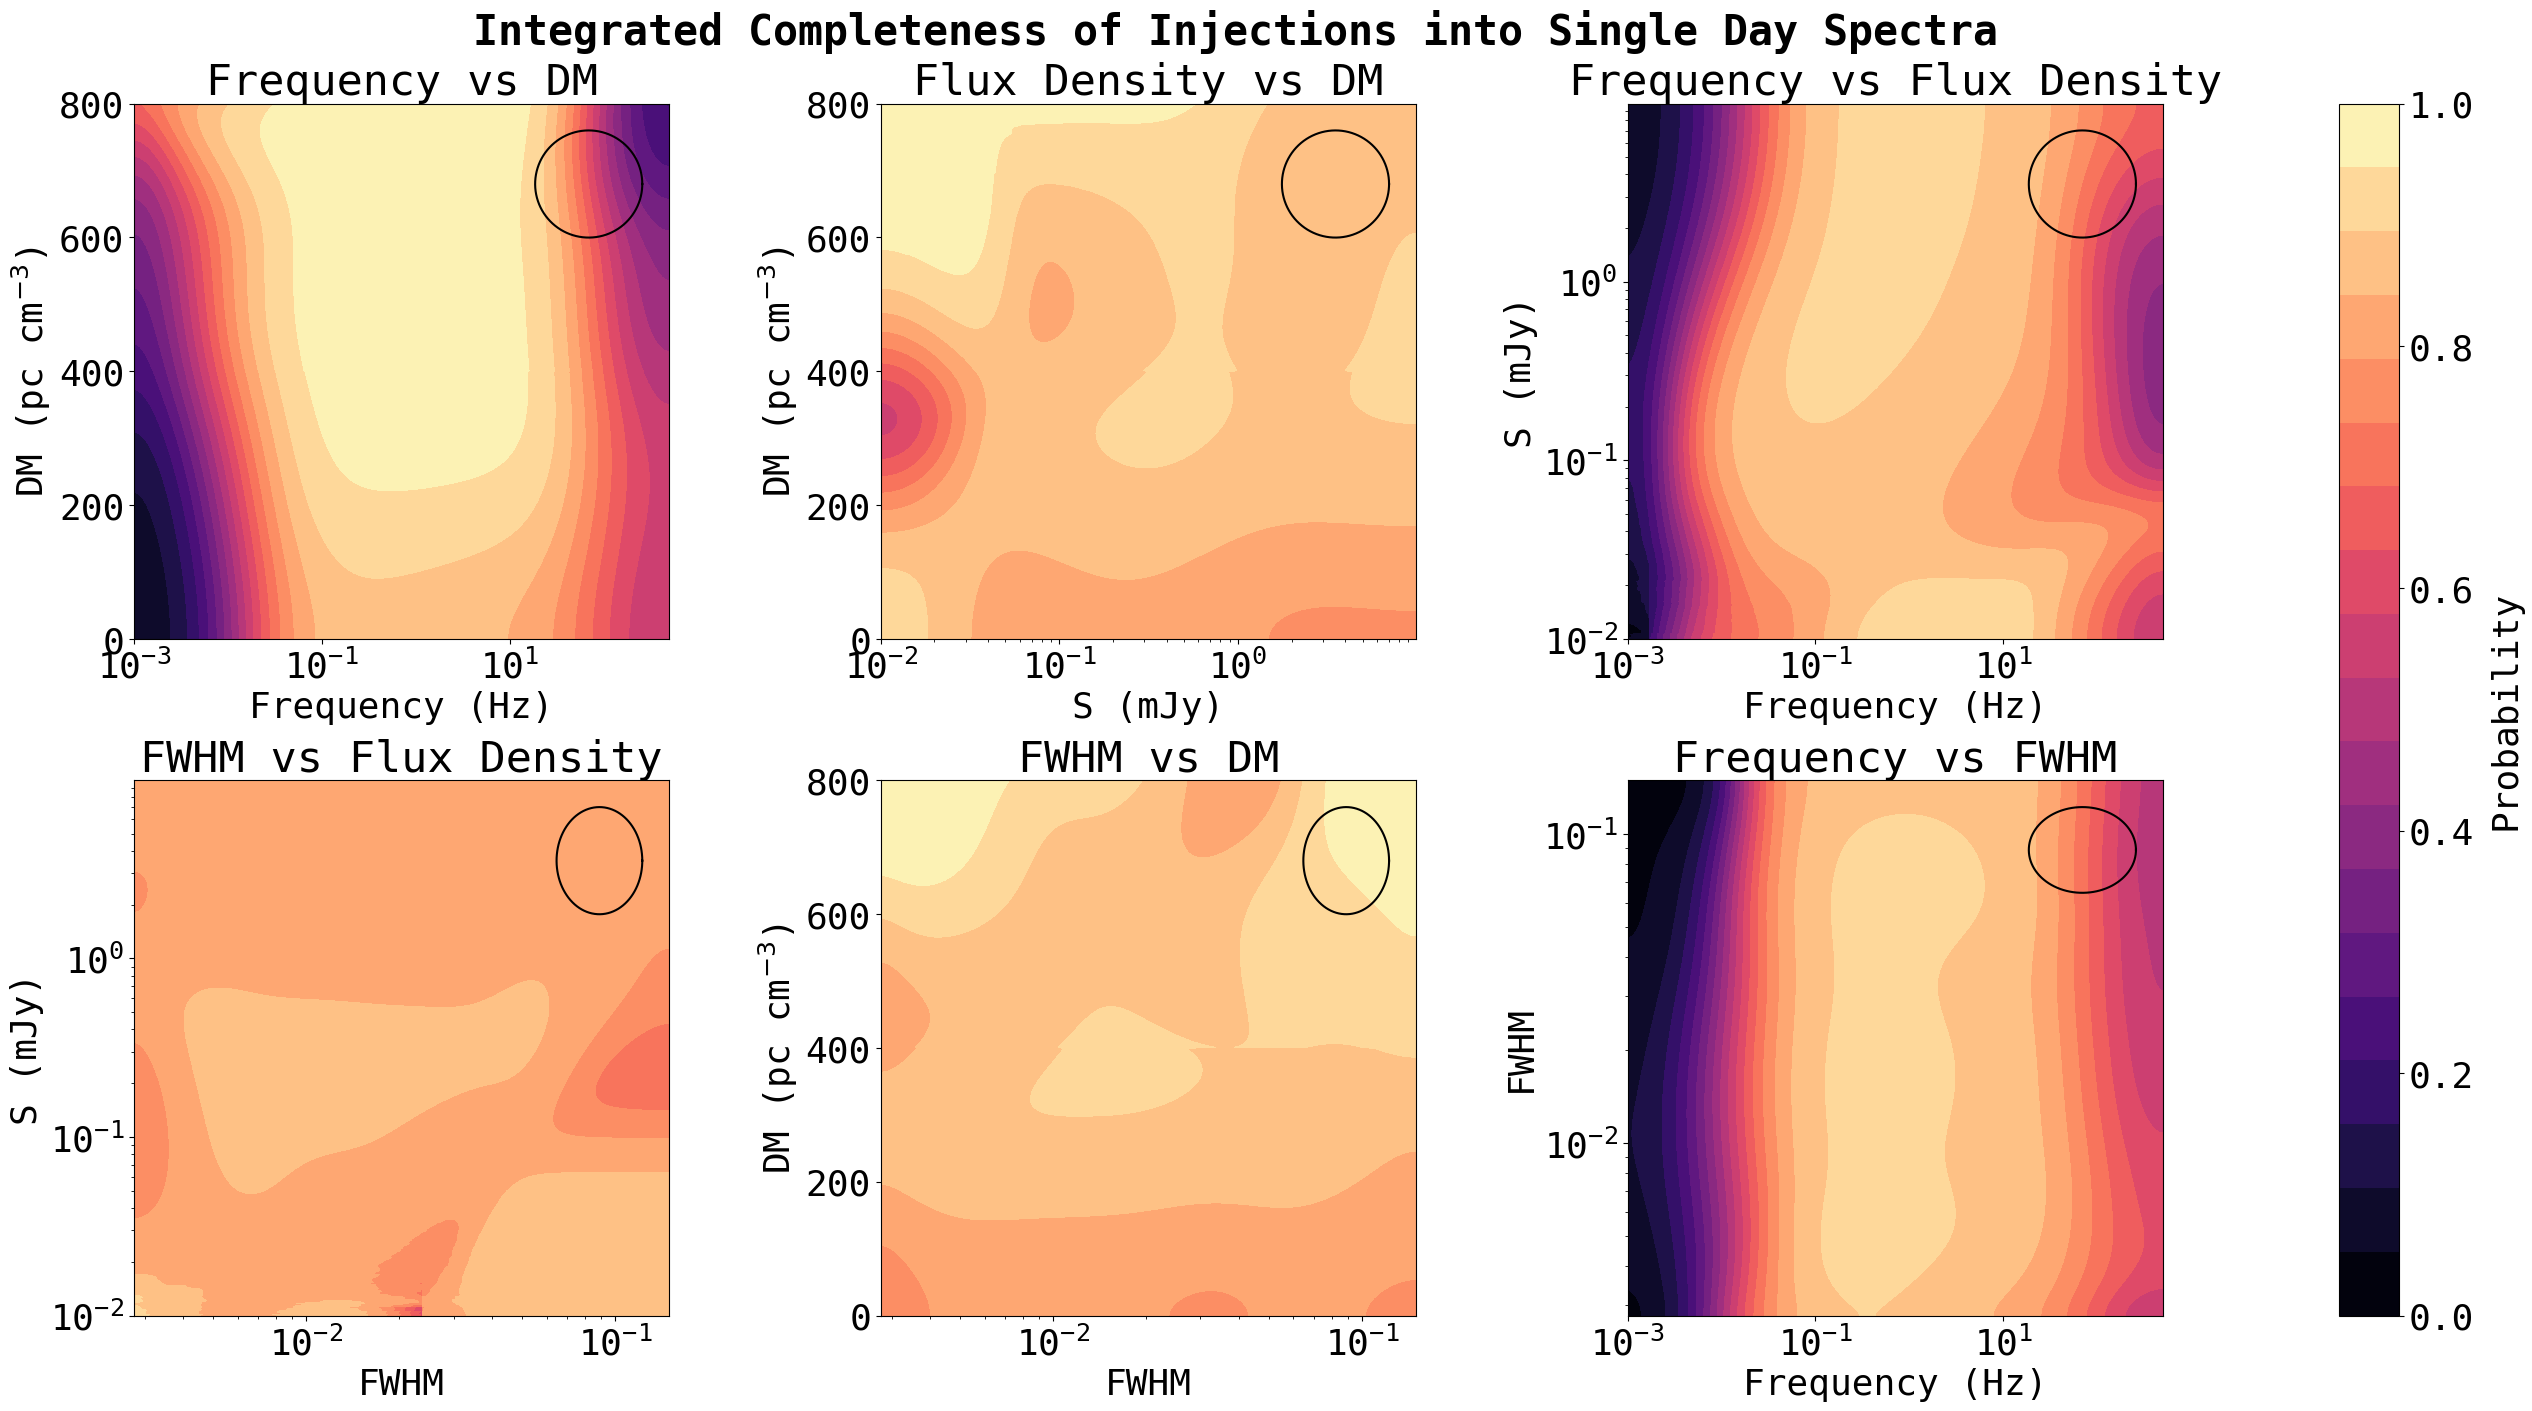

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(26, 14), layout = 'constrained')
ax = ax.flatten()
import importlib
importlib.reload(au)

#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_ret_p_smooth_1, 
                           levels=au.make_levels(dm_f_ret_p_smooth_1),cmap='magma')
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
ax[0].set_ylim(0, 800)
ax[0].set_box_aspect(1)
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True, color = 'black')

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_ret_p_smooth_1, 
                           levels=au.make_levels(dm_s_ret_p_smooth_1), cmap='magma')
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
#ax[1].set_xlim(1e-1, max(S_bins) - 1)
ax[1].set_ylim(0, 800)
ax[1].set_box_aspect(1)
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True, color = 'black')

#f vs S
cf2 = ax[2].contourf(f_bins[:-1], S_bins[:-1], s_f_ret_p_smooth_1, 
                           levels=au.make_levels(s_f_ret_p_smooth_1), cmap='magma')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('S (mJy)')
ax[2].set_title('Frequency vs Flux Density')
ax[2].set_box_aspect(1)
#ax[2].set_xlim(1e-2, max(f_bins))
#ax[2].set_ylim(1e-1, max(S_bins) - 1)
au.add_ellipse(ax[2], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True, color = 'black')

#FWHM vs S
cf3 = ax[3].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_ret_p_smooth_1, 
                           levels=au.make_levels(s_fwhm_ret_p_smooth_1), cmap='magma')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('FWHM vs Flux Density')
ax[3].set_box_aspect(1)
#ax[3].set_ylim(5e-2, max(S_bins) -1 )
au.add_ellipse(ax[3], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True, color = 'black')

#FWHM vs DM
cf4 = ax[4].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_ret_p_smooth_1, 
                           levels=au.make_levels(dm_fwhm_ret_p_smooth_1), cmap='magma')
ax[4].set_xscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[4].set_title('FWHM vs DM')
ax[4].set_ylim(0, 800)
ax[4].set_xlim(fwhm_bins[0], fwhm_bins[-2])
ax[4].set_box_aspect(1)
au.add_ellipse(ax[4], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True, color = 'black')

#f vs FWHM
cf5 = ax[5].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_ret_p_smooth_1, 
                           levels=au.make_levels(fwhm_f_ret_p_smooth_1), cmap='magma')
ax[5].set_xscale('log')
ax[5].set_yscale('log')
ax[5].set_xlabel('Frequency (Hz)')
ax[5].set_ylabel('FWHM')
ax[5].set_title('Frequency vs FWHM')
ax[5].set_box_aspect(1)
ax[5].set_ylim(fwhm_bins[0], fwhm_bins[-2])
#ax[5].set_xlim(1e-2, max(f_bins))
au.add_ellipse(ax[5], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True, color = 'black')

cbar = fig.colorbar(cf5, ax=ax, location='right', pad=0.08)
cbar.set_label('Probability', labelpad=10)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.suptitle('Integrated Completeness of Injections into Single Day Spectra', 
             fontsize=30, fontweight='bold')
plt.show()

Same thing but the missed injections difference map:

In [12]:
sigma_mask = (data_1[:, 8] > 6.) 

_, _, dm_f_ret_all = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)
_, _, dm_f_ret_first = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_f_weird_harm = dm_f_ret_all - dm_f_ret_first

_, _, dm_s_ret_all = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)
_, _, dm_s_ret_first = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_s_weird_harm = dm_s_ret_all - dm_s_ret_first

_, _, s_f_ret_all = au.get_sensitivity(
    data_1[sigma_mask],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)
_, _, s_f_ret_first = au.get_sensitivity(
    data_1[sigma_mask],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
s_f_weird_harm = s_f_ret_all - s_f_ret_first

_, _, s_fwhm_ret_all = au.get_sensitivity(
    data_1[sigma_mask],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)
_, _, s_fwhm_ret_first = au.get_sensitivity(
    data_1[sigma_mask],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
    def_retrieval = 1,
)
s_fwhm_weird_harm = s_fwhm_ret_all - s_fwhm_ret_first

_, _, dm_fwhm_ret_all = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)
_, _, dm_fwhm_ret_first = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_fwhm_weird_harm = dm_fwhm_ret_all - dm_fwhm_ret_first

_, _, fwhm_f_ret_all = au.get_sensitivity(
    data_1[sigma_mask],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)
_, _, fwhm_f_ret_first = au.get_sensitivity(
    data_1[sigma_mask],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
fwhm_f_weird_harm = fwhm_f_ret_all - fwhm_f_ret_first

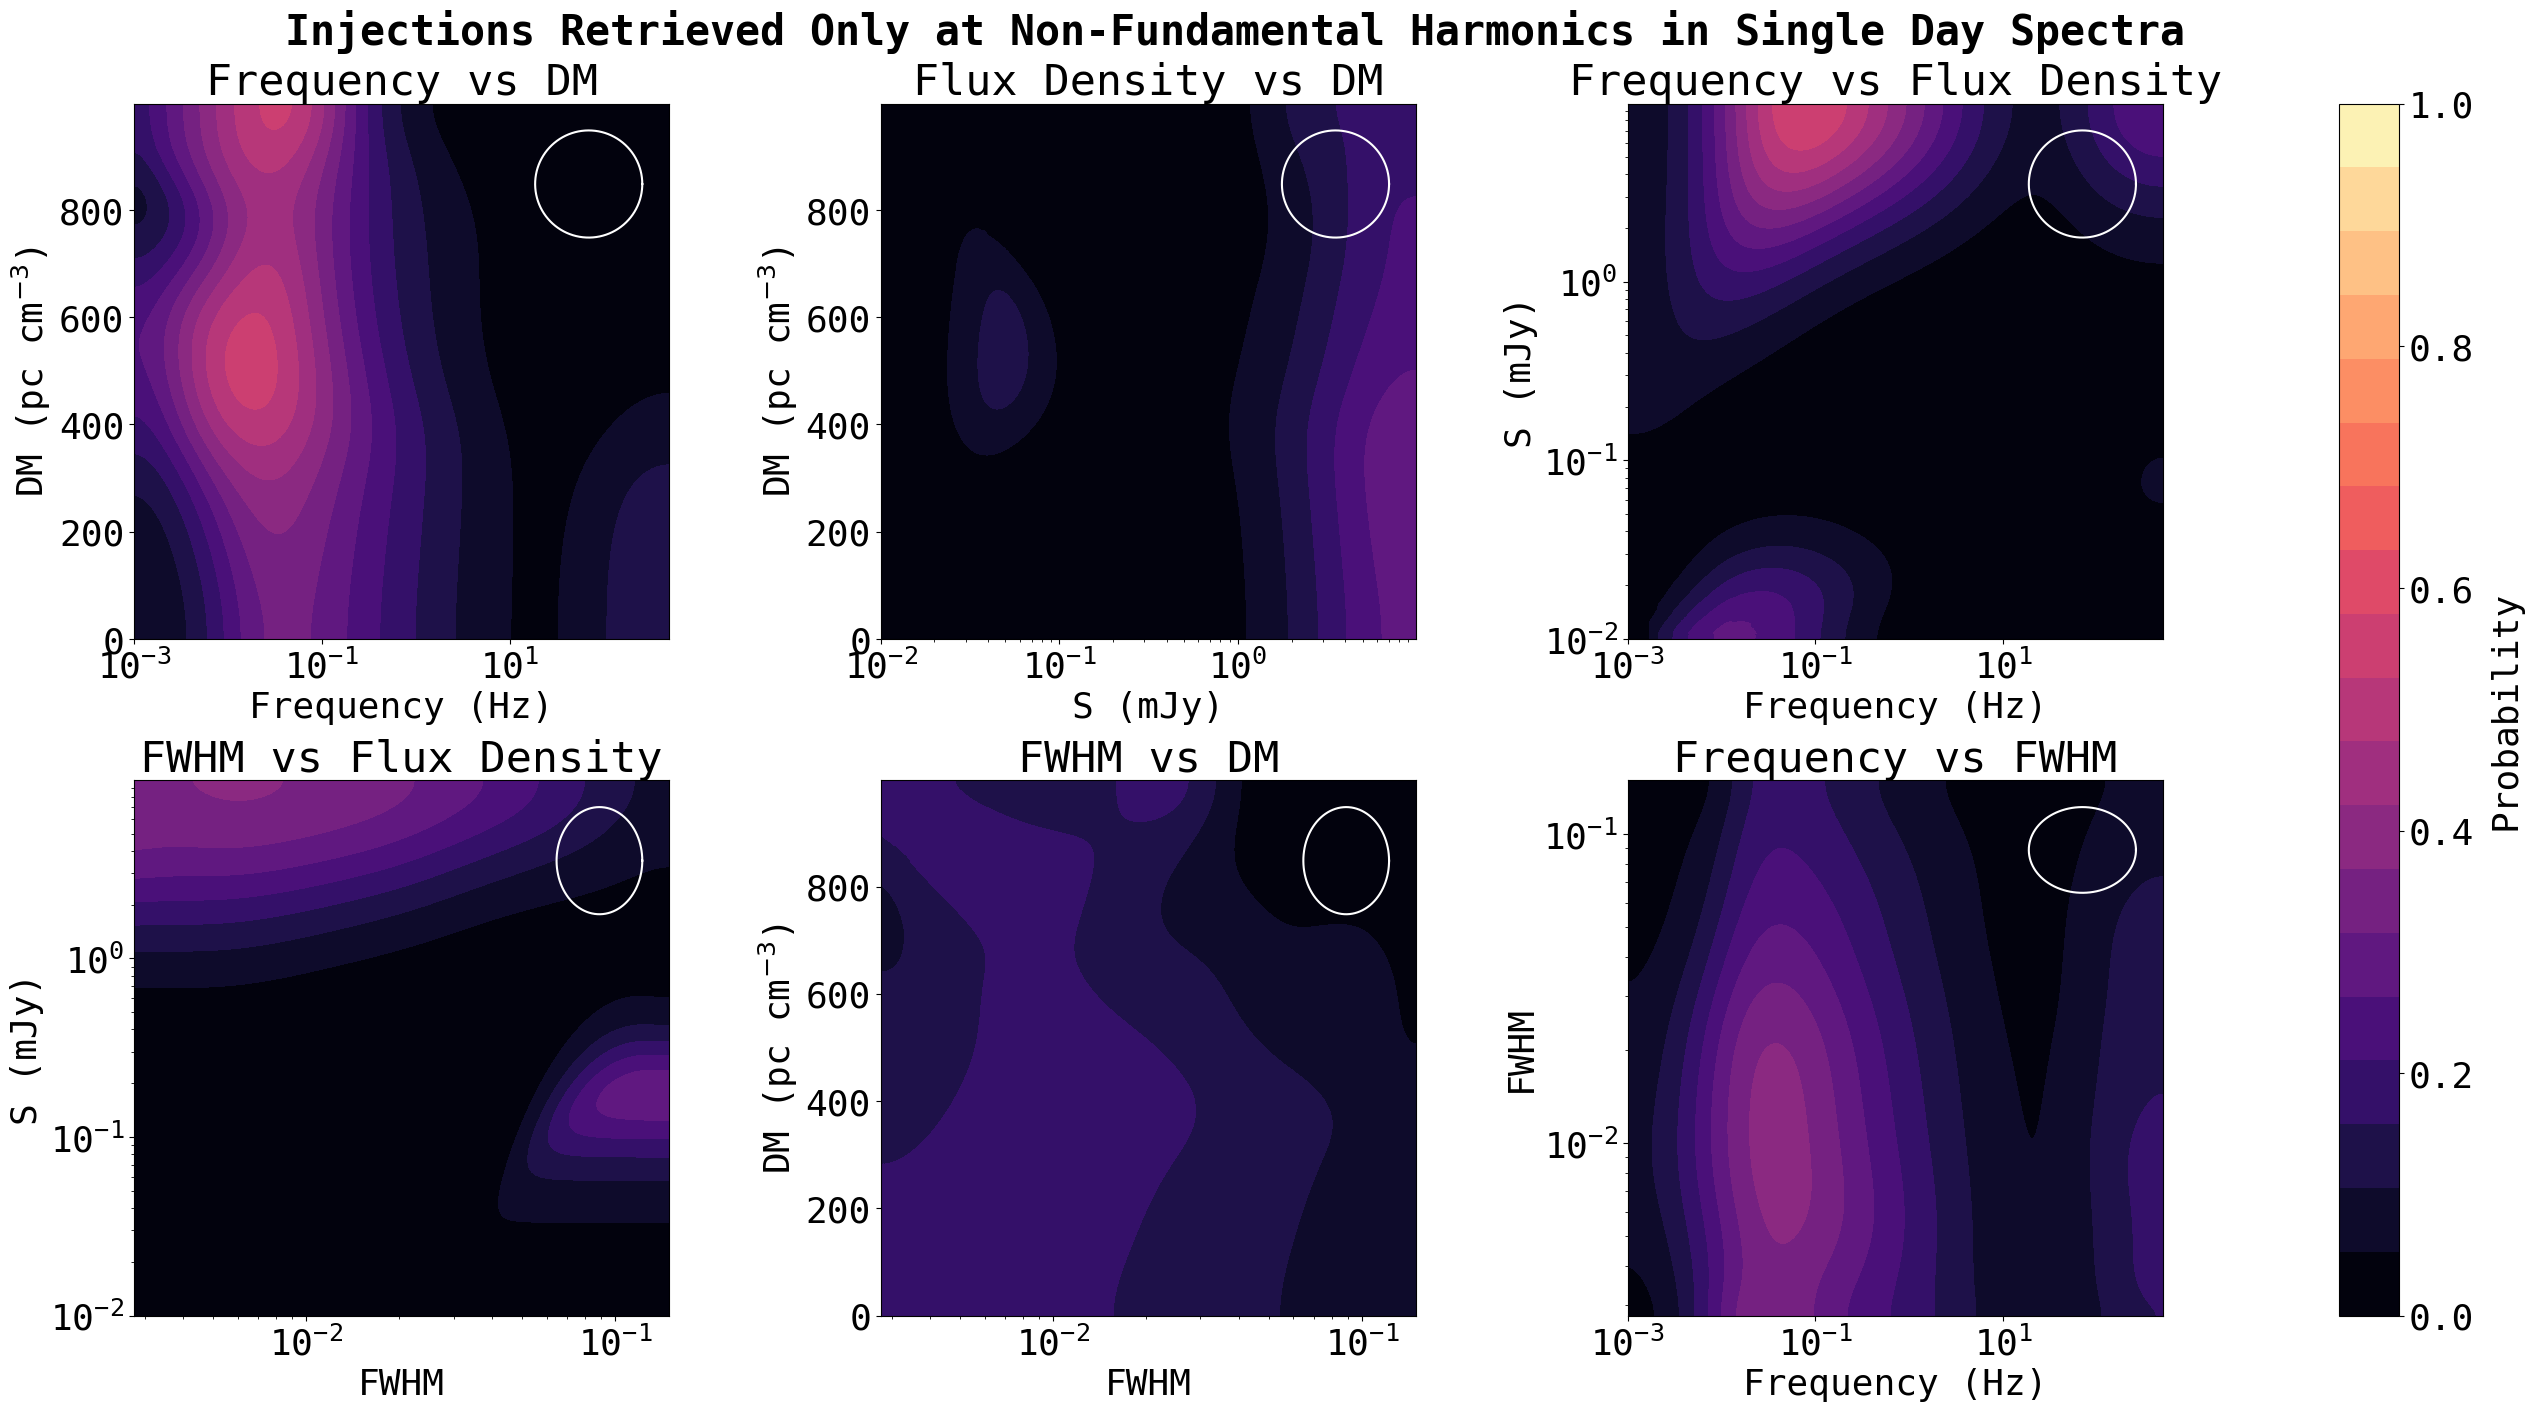

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(26, 14), layout = 'constrained')
ax = ax.flatten()
import importlib
importlib.reload(au)

#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_weird_harm, 
                           levels=au.make_levels(dm_f_weird_harm),cmap='magma')
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
#ax[0].set_xlim(1e-2, max(f_bins))
#ax[0].set_ylim(0, 700)
ax[0].set_box_aspect(1)
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_weird_harm, 
                           levels=au.make_levels(dm_s_weird_harm), cmap='magma')
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
#ax[1].set_xlim(1e-1, max(S_bins) - 1)
#ax[1].set_ylim(0, 700)
ax[1].set_box_aspect(1)
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = ax[2].contourf(f_bins[:-1], S_bins[:-1], s_f_weird_harm, 
                           levels=au.make_levels(s_f_weird_harm), cmap='magma')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('S (mJy)')
ax[2].set_title('Frequency vs Flux Density')
ax[2].set_box_aspect(1)
#ax[2].set_xlim(1e-2, max(f_bins))
#ax[2].set_ylim(1e-1, max(S_bins) - 1)
au.add_ellipse(ax[2], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = ax[3].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_weird_harm, 
                           levels=au.make_levels(s_fwhm_weird_harm), cmap='magma')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('FWHM vs Flux Density')
ax[3].set_box_aspect(1)
#ax[3].set_ylim(5e-2, max(S_bins) -1 )
au.add_ellipse(ax[3], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = ax[4].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_weird_harm, 
                           levels=au.make_levels(dm_fwhm_weird_harm), cmap='magma')
ax[4].set_xscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[4].set_title('FWHM vs DM')
#ax[4].set_ylim(0, 700)
ax[4].set_xlim(fwhm_bins[0], fwhm_bins[-2])
ax[4].set_box_aspect(1)
au.add_ellipse(ax[4], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = ax[5].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_weird_harm, 
                           levels=au.make_levels(fwhm_f_weird_harm), cmap='magma')
ax[5].set_xscale('log')
ax[5].set_yscale('log')
ax[5].set_xlabel('Frequency (Hz)')
ax[5].set_ylabel('FWHM')
ax[5].set_title('Frequency vs FWHM')
ax[5].set_box_aspect(1)
ax[5].set_ylim(fwhm_bins[0], fwhm_bins[-2])
#ax[5].set_xlim(1e-2, max(f_bins))
au.add_ellipse(ax[5], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

cbar = fig.colorbar(cf5, ax=ax, location='right', pad=0.08)
cbar.set_label('Probability', labelpad=10)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.suptitle('Injections Retrieved Only at Non-Fundamental Harmonics in Single Day Spectra', 
             fontsize=30, fontweight='bold')
plt.show()

Now stacks...

In [14]:
data_13 = np.loadtxt('13_day_injections_04_06.txt')
print(f'Number of pointings: {len(np.unique(data_13[:, 0:2], axis=0))}')
print(f'Total fraction of recovered injections: {(100*len(data_13[data_13[:, -1] > 0.])/len(data_13)):.2f}%')
print(f'Number of injections: {len(data_13)}')
RA = data_13[:, 0]
Dec = data_13[:, 1]
f = data_13[:, 4]
DM = data_13[:, 5]
S = data_13[:, 6]
fwhm = data_13[:, 7]

Number of pointings: 1964
Total fraction of recovered injections: 41.00%
Number of injections: 20070


In [15]:
# RA_bins = np.arange(min(RA), max(RA), 0.5)
# Dec_bins = np.arange(min(Dec), max(Dec), 0.5)
# f_bins = np.logspace(np.log10(min(f)), np.log10(max(f)), 1000)
# DM_bins = np.arange(min(DM), 1000)
# S_bins = np.logspace(np.log10(min(S)), np.log10(max(S)), 1000)
# fwhm_bins = np.logspace(np.log10(min(fwhm)), np.log10(0.15), 1000)

In [16]:
# f_dev = 100
# DM_dev = 100
# S_dev = 100
# FWHM_dev = 80

In [17]:
dm_f_inj_p_smooth_13, dm_f_ret_p_13, dm_f_ret_p_smooth_13 = au.get_sensitivity(
    data_13,
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

dm_s_inj_p_smooth_13, dm_s_ret_p_13, dm_s_ret_p_smooth_13 = au.get_sensitivity(
    data_13,
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

s_f_inj_p_smooth_13, s_f_ret_p_13, s_f_ret_p_smooth_13 = au.get_sensitivity(
    data_13,
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

s_fwhm_inj_p_smooth_13, s_fwhm_ret_p_13, s_fwhm_ret_p_smooth_13 = au.get_sensitivity(
    data_13,
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

dm_fwhm_inj_p_smooth_13, dm_fwhm_ret_p_13, dm_fwhm_ret_p_smooth_13 = au.get_sensitivity(
    data_13,
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

fwhm_f_inj_p_smooth_13, fwhm_f_ret_p_13, fwhm_f_ret_p_smooth_13 = au.get_sensitivity(
    data_13,
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

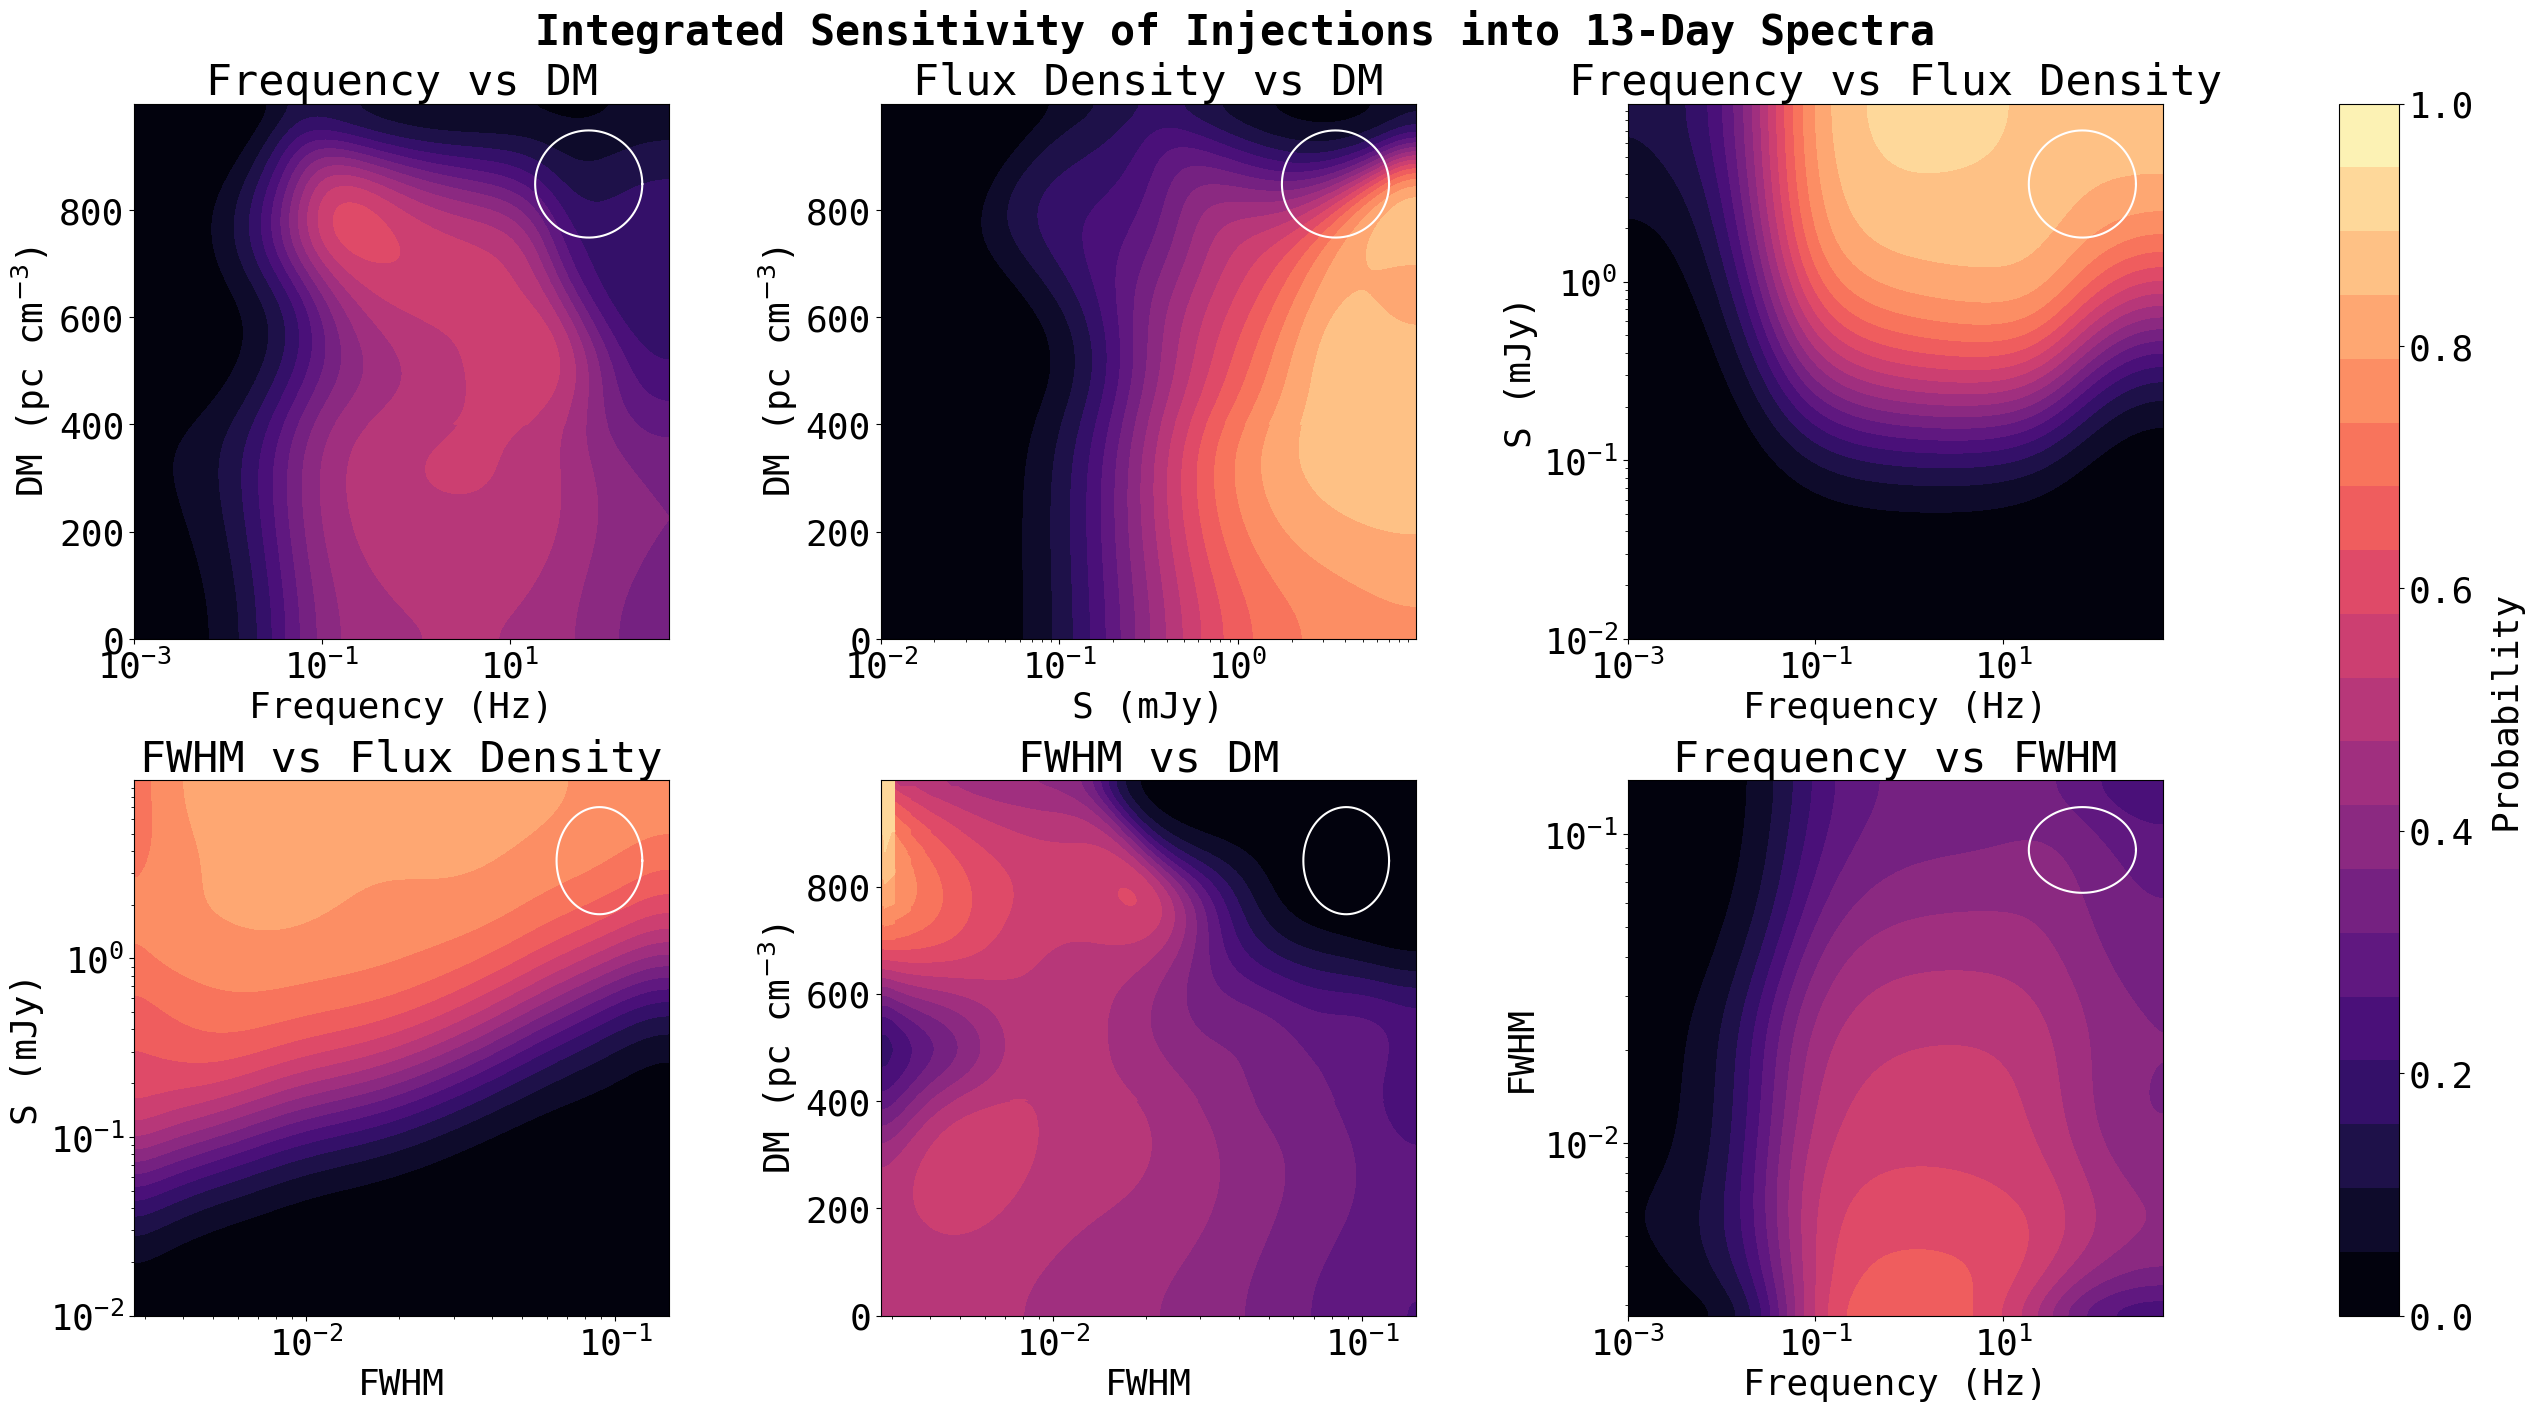

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(26, 14), layout = 'constrained')
ax = ax.flatten()

#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_ret_p_smooth_13, 
                           levels=au.make_levels(dm_f_ret_p_smooth_13),cmap='magma')
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
#ax[0].set_xlim(1e-2, max(f_bins))
#ax[0].set_ylim(0, 700)
ax[0].set_box_aspect(1)
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_ret_p_smooth_13, 
                           levels=au.make_levels(dm_s_ret_p_smooth_13), cmap='magma')
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
#ax[1].set_xlim(1e-1, max(S_bins) - 1)
#ax[1].set_ylim(0, 700)
ax[1].set_box_aspect(1)
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = ax[2].contourf(f_bins[:-1], S_bins[:-1], s_f_ret_p_smooth_13, 
                           levels=au.make_levels(s_f_ret_p_smooth_13), cmap='magma')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('S (mJy)')
ax[2].set_title('Frequency vs Flux Density')
ax[2].set_box_aspect(1)
#ax[2].set_xlim(1e-2, max(f_bins))
#ax[2].set_ylim(1e-1, max(S_bins) - 1)
au.add_ellipse(ax[2], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = ax[3].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_ret_p_smooth_13, 
                           levels=au.make_levels(s_fwhm_ret_p_smooth_13), cmap='magma')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('FWHM vs Flux Density')
ax[3].set_box_aspect(1)
#ax[3].set_ylim(5e-2, max(S_bins) -1 )
au.add_ellipse(ax[3], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = ax[4].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_ret_p_smooth_13, 
                           levels=au.make_levels(dm_fwhm_ret_p_smooth_13), cmap='magma')
ax[4].set_xscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[4].set_title('FWHM vs DM')
#ax[4].set_ylim(0, 700)
ax[4].set_xlim(fwhm_bins[0], fwhm_bins[-2])
ax[4].set_box_aspect(1)
au.add_ellipse(ax[4], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = ax[5].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_ret_p_smooth_13, 
                           levels=au.make_levels(fwhm_f_ret_p_smooth_13), cmap='magma')
ax[5].set_xscale('log')
ax[5].set_yscale('log')
ax[5].set_xlabel('Frequency (Hz)')
ax[5].set_ylabel('FWHM')
ax[5].set_title('Frequency vs FWHM')
ax[5].set_box_aspect(1)
ax[5].set_ylim(fwhm_bins[0], fwhm_bins[-2])
#ax[5].set_xlim(1e-2, max(f_bins))
au.add_ellipse(ax[5], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

cbar = fig.colorbar(cf5, ax=ax, location='right', pad=0.08)
cbar.set_label('Probability', labelpad=10)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.suptitle('Integrated Sensitivity of Injections into 13-Day Spectra', 
             fontsize=30, fontweight='bold')
plt.show()

In [19]:
S_mask = data_13[:, 6] < 0.1
retrieved_mask = data_13[:, -1] > 0
data_13_low_flux = data_13[S_mask]
data_13_low_flux_retrieved = data_13[S_mask & retrieved_mask]
100*len(data_13_low_flux_retrieved) / len(data_13_low_flux)

0.6550883607556368

In [20]:
sigma_mask = data_1[:, 8] > 6.

dm_f_inj_p_smooth_13, _, dm_f_ret_p_smooth_13 = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

dm_s_inj_p_smooth_13, _, dm_s_ret_p_smooth_13 = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

s_f_inj_p_smooth_13, _, s_f_ret_p_smooth_13 = au.get_sensitivity(
    data_1[sigma_mask],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

s_fwhm_inj_p_smooth_13, _, s_fwhm_ret_p_smooth_13 = au.get_sensitivity(
    data_1[sigma_mask],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

dm_fwhm_inj_p_smooth_13, _, dm_fwhm_ret_p_smooth_13 = au.get_sensitivity(
    data_1[sigma_mask],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

fwhm_f_inj_p_smooth_13, _, fwhm_f_ret_p_smooth_13 = au.get_sensitivity(
    data_1[sigma_mask],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

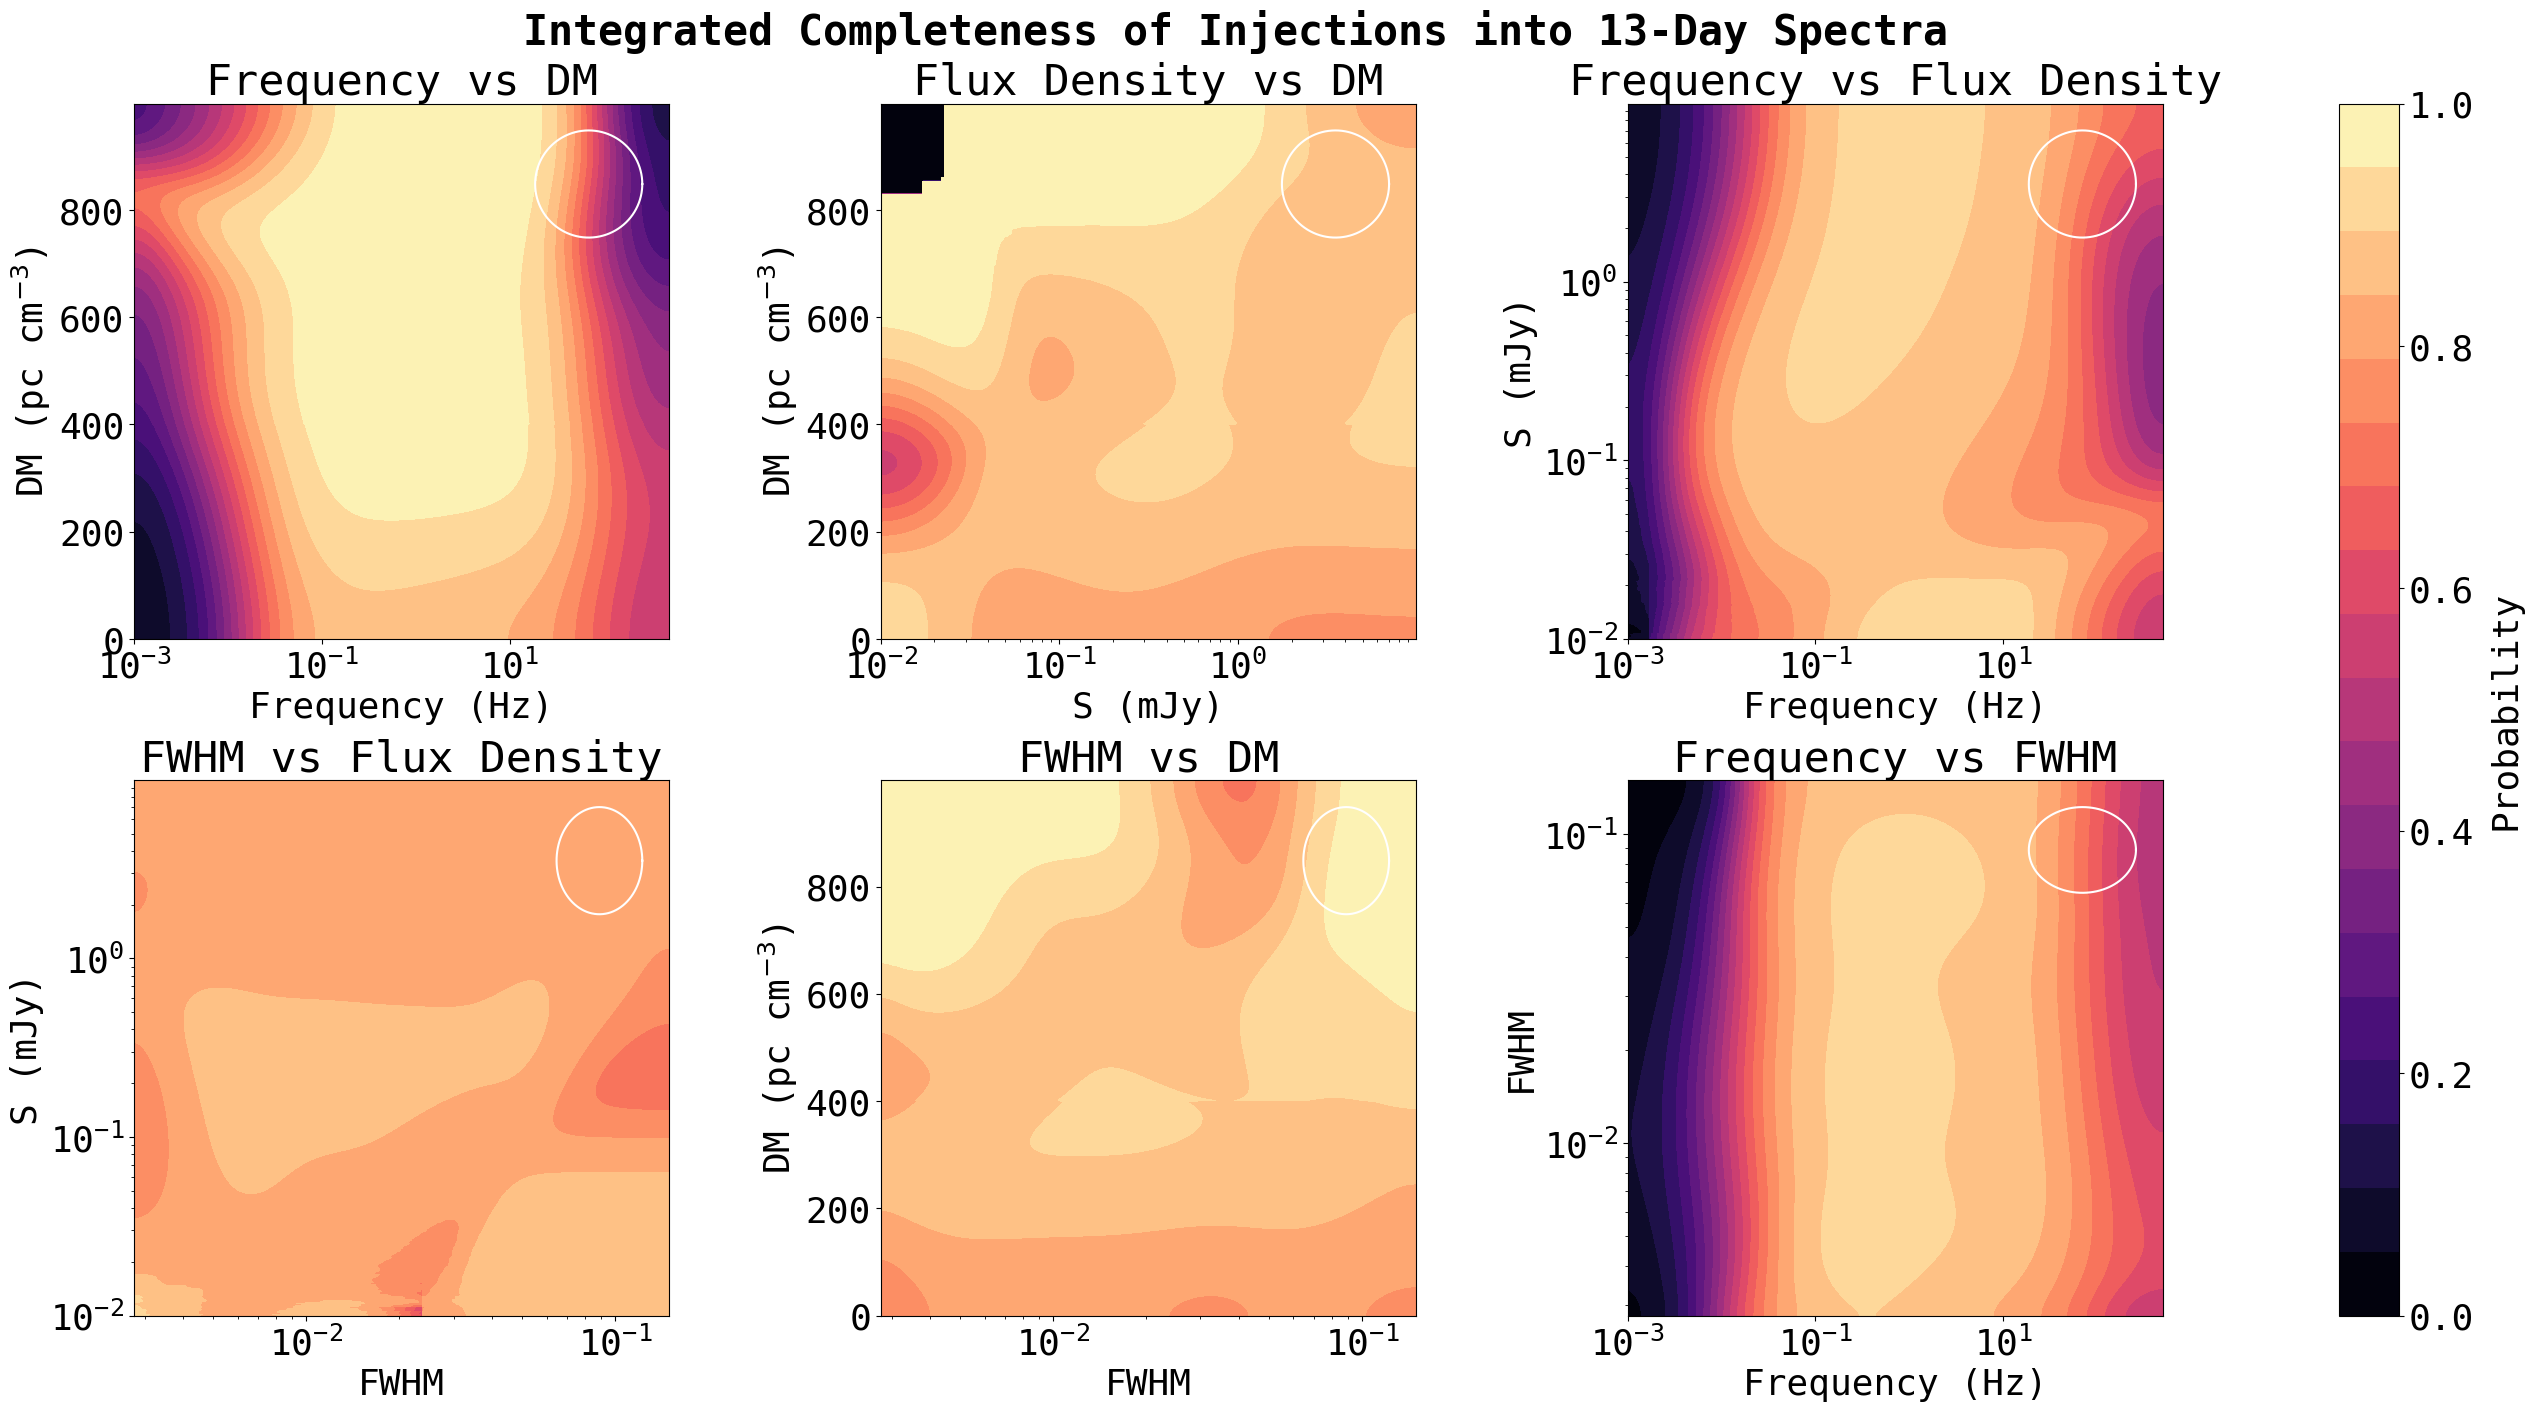

In [21]:
fig, ax = plt.subplots(2, 3, figsize=(26, 14), layout = 'constrained')
ax = ax.flatten()
import importlib
importlib.reload(au)

#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_ret_p_smooth_13, 
                           levels=au.make_levels(dm_f_ret_p_smooth_13),cmap='magma')
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
#ax[0].set_xlim(1e-2, max(f_bins))
#ax[0].set_ylim(0, 700)
ax[0].set_box_aspect(1)
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_ret_p_smooth_13, 
                           levels=au.make_levels(dm_s_ret_p_smooth_13), cmap='magma')
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
#ax[1].set_xlim(1e-1, max(S_bins) - 1)
#ax[1].set_ylim(0, 700)
ax[1].set_box_aspect(1)
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = ax[2].contourf(f_bins[:-1], S_bins[:-1], s_f_ret_p_smooth_13, 
                           levels=au.make_levels(s_f_ret_p_smooth_13), cmap='magma')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('S (mJy)')
ax[2].set_title('Frequency vs Flux Density')
ax[2].set_box_aspect(1)
#ax[2].set_xlim(1e-2, max(f_bins))
#ax[2].set_ylim(1e-1, max(S_bins) - 1)
au.add_ellipse(ax[2], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = ax[3].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_ret_p_smooth_13, 
                           levels=au.make_levels(s_fwhm_ret_p_smooth_13), cmap='magma')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('FWHM vs Flux Density')
ax[3].set_box_aspect(1)
#ax[3].set_ylim(5e-2, max(S_bins) -1 )
au.add_ellipse(ax[3], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = ax[4].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_ret_p_smooth_13, 
                           levels=au.make_levels(dm_fwhm_ret_p_smooth_13), cmap='magma')
ax[4].set_xscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[4].set_title('FWHM vs DM')
#ax[4].set_ylim(0, 700)
ax[4].set_xlim(fwhm_bins[0], fwhm_bins[-2])
ax[4].set_box_aspect(1)
au.add_ellipse(ax[4], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = ax[5].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_ret_p_smooth_13, 
                           levels=au.make_levels(fwhm_f_ret_p_smooth_13), cmap='magma')
ax[5].set_xscale('log')
ax[5].set_yscale('log')
ax[5].set_xlabel('Frequency (Hz)')
ax[5].set_ylabel('FWHM')
ax[5].set_title('Frequency vs FWHM')
ax[5].set_box_aspect(1)
ax[5].set_ylim(fwhm_bins[0], fwhm_bins[-2])
#ax[5].set_xlim(1e-2, max(f_bins))
au.add_ellipse(ax[5], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

cbar = fig.colorbar(cf5, ax=ax, location='right', pad=0.08)
cbar.set_label('Probability', labelpad=10)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.suptitle('Integrated Completeness of Injections into 13-Day Spectra', 
             fontsize=30, fontweight='bold')
plt.show()

In [22]:
sigma_mask = (data_13[:, 8] > 6.) 

_, _, dm_f_ret_all = au.get_sensitivity(
    data_13[sigma_mask],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)
_, _, dm_f_ret_first = au.get_sensitivity(
    data_13[sigma_mask],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_f_weird_harm_13 = dm_f_ret_all - dm_f_ret_first

_, _, dm_s_ret_all = au.get_sensitivity(
    data_13[sigma_mask],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)
_, _, dm_s_ret_first = au.get_sensitivity(
    data_13[sigma_mask],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_s_weird_harm_13 = dm_s_ret_all - dm_s_ret_first

_, _, s_f_ret_all = au.get_sensitivity(
    data_13[sigma_mask],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)
_, _, s_f_ret_first = au.get_sensitivity(
    data_13[sigma_mask],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
s_f_weird_harm_13 = s_f_ret_all - s_f_ret_first

_, _, s_fwhm_ret_all = au.get_sensitivity(
    data_13[sigma_mask],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)
_, _, s_fwhm_ret_first = au.get_sensitivity(
    data_13[sigma_mask],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
    def_retrieval = 1,
)
s_fwhm_weird_harm_13 = s_fwhm_ret_all - s_fwhm_ret_first

_, _, dm_fwhm_ret_all = au.get_sensitivity(
    data_13[sigma_mask],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)
_, _, dm_fwhm_ret_first = au.get_sensitivity(
    data_13[sigma_mask],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_fwhm_weird_harm_13 = dm_fwhm_ret_all - dm_fwhm_ret_first

_, _, fwhm_f_ret_all = au.get_sensitivity(
    data_13[sigma_mask],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)
_, _, fwhm_f_ret_first = au.get_sensitivity(
    data_13[sigma_mask],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
fwhm_f_weird_harm_13 = fwhm_f_ret_all - fwhm_f_ret_first

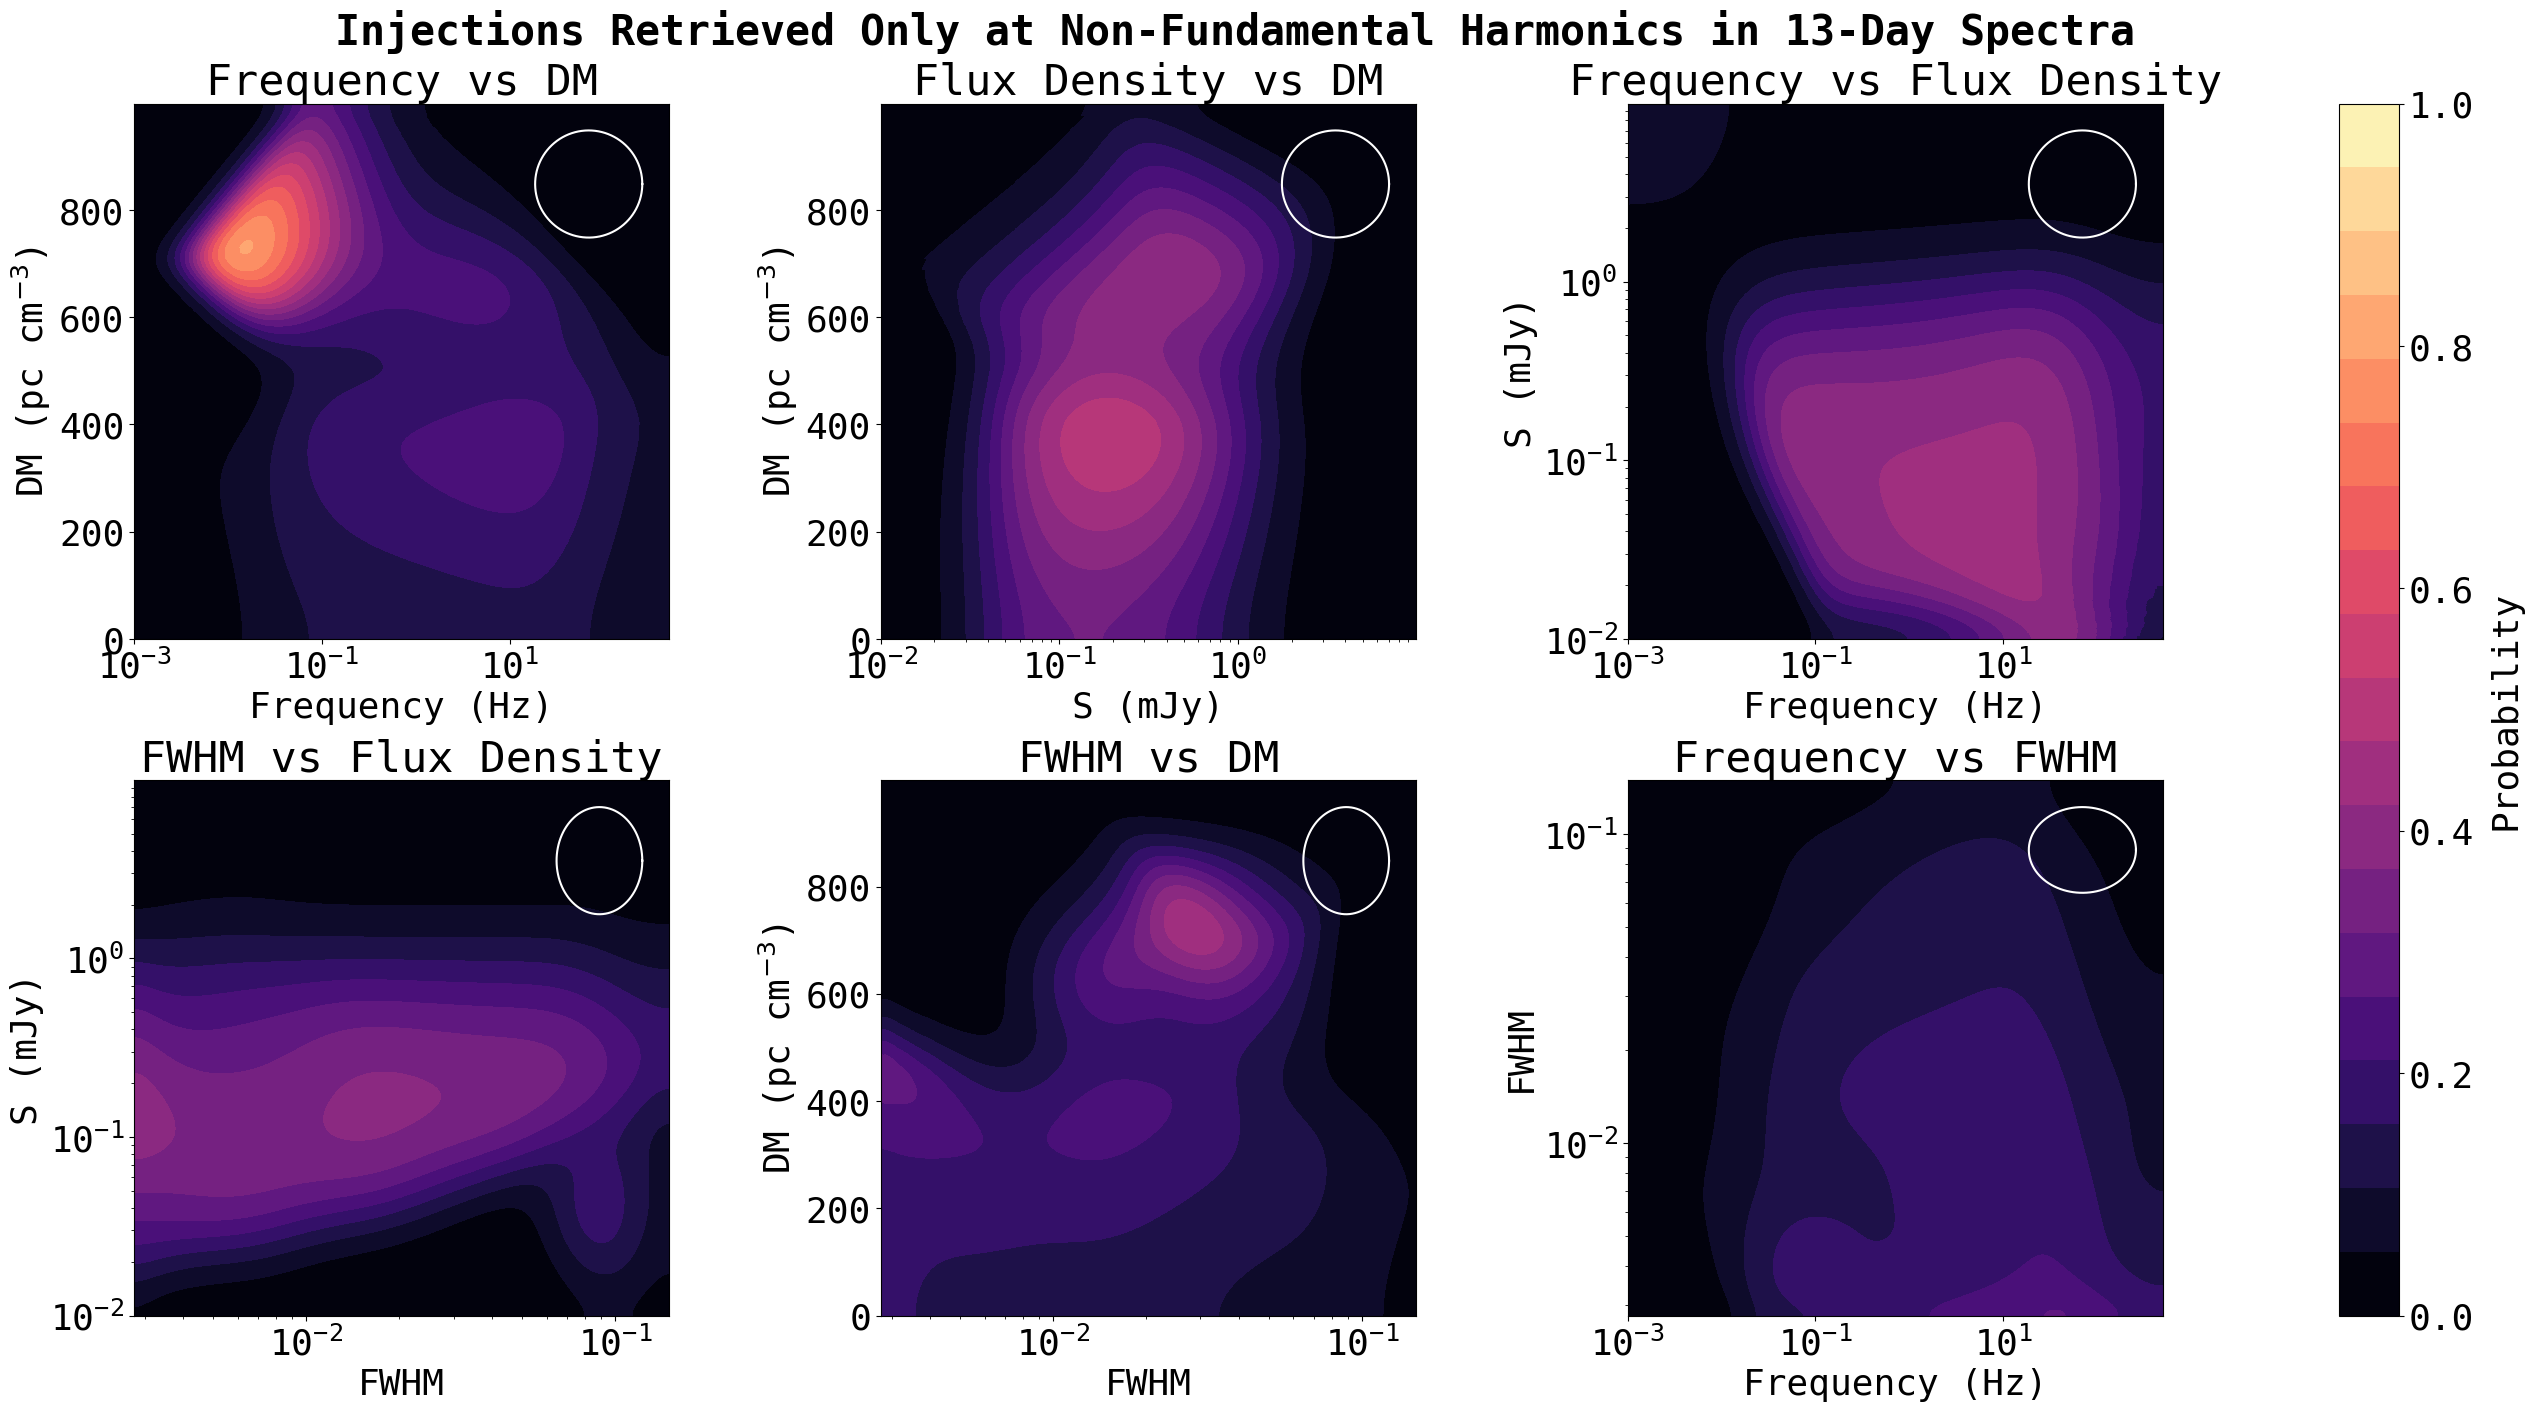

In [23]:
fig, ax = plt.subplots(2, 3, figsize=(26, 14), layout = 'constrained')
ax = ax.flatten()
import importlib
importlib.reload(au)

#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_weird_harm_13, 
                           levels=au.make_levels(dm_f_weird_harm_13),cmap='magma')
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
#ax[0].set_xlim(1e-2, max(f_bins))
#ax[0].set_ylim(0, 700)
ax[0].set_box_aspect(1)
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_weird_harm_13, 
                           levels=au.make_levels(dm_s_weird_harm_13), cmap='magma')
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
#ax[1].set_xlim(1e-1, max(S_bins) - 1)
#ax[1].set_ylim(0, 700)
ax[1].set_box_aspect(1)
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = ax[2].contourf(f_bins[:-1], S_bins[:-1], s_f_weird_harm_13, 
                           levels=au.make_levels(s_f_weird_harm_13), cmap='magma')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('S (mJy)')
ax[2].set_title('Frequency vs Flux Density')
ax[2].set_box_aspect(1)
#ax[2].set_xlim(1e-2, max(f_bins))
#ax[2].set_ylim(1e-1, max(S_bins) - 1)
au.add_ellipse(ax[2], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = ax[3].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_weird_harm_13, 
                           levels=au.make_levels(s_fwhm_weird_harm_13), cmap='magma')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('FWHM vs Flux Density')
ax[3].set_box_aspect(1)
#ax[3].set_ylim(5e-2, max(S_bins) -1 )
au.add_ellipse(ax[3], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = ax[4].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_weird_harm_13, 
                           levels=au.make_levels(dm_fwhm_weird_harm_13), cmap='magma')
ax[4].set_xscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[4].set_title('FWHM vs DM')
#ax[4].set_ylim(0, 700)
ax[4].set_xlim(fwhm_bins[0], fwhm_bins[-2])
ax[4].set_box_aspect(1)
au.add_ellipse(ax[4], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = ax[5].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_weird_harm_13, 
                           levels=au.make_levels(fwhm_f_weird_harm_13), cmap='magma')
ax[5].set_xscale('log')
ax[5].set_yscale('log')
ax[5].set_xlabel('Frequency (Hz)')
ax[5].set_ylabel('FWHM')
ax[5].set_title('Frequency vs FWHM')
ax[5].set_box_aspect(1)
ax[5].set_ylim(fwhm_bins[0], fwhm_bins[-2])
#ax[5].set_xlim(1e-2, max(f_bins))
au.add_ellipse(ax[5], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

cbar = fig.colorbar(cf5, ax=ax, location='right', pad=0.08)
cbar.set_label('Probability', labelpad=10)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.suptitle('Injections Retrieved Only at Non-Fundamental Harmonics in 13-Day Spectra', 
             fontsize=30, fontweight='bold')
plt.show()

Difference between the two...

In [24]:
dm_f_diff = dm_f_ret_p_13 - dm_f_ret_p_1
dm_s_diff = dm_s_ret_p_13 - dm_s_ret_p_1
s_f_diff = s_f_ret_p_13 - s_f_ret_p_1
s_fwhm_diff = s_fwhm_ret_p_13 - s_fwhm_ret_p_1
dm_fwhm_diff = dm_fwhm_ret_p_13 - dm_fwhm_ret_p_1
fwhm_f_diff = fwhm_f_ret_p_13 - fwhm_f_ret_p_1

dm_f_diff_smooth = gaussian_filter(dm_f_diff, (DM_dev, f_dev))
dm_s_diff_smooth = gaussian_filter(dm_s_diff, (DM_dev, S_dev))
s_f_diff_smooth = gaussian_filter(s_f_diff, (S_dev, f_dev))
s_fwhm_diff_smooth = gaussian_filter(s_fwhm_diff, (S_dev, FWHM_dev))
dm_fwhm_diff_smooth = gaussian_filter(dm_fwhm_diff, (DM_dev, FWHM_dev))
fwhm_f_diff_smooth = gaussian_filter(fwhm_f_diff, (FWHM_dev, f_dev))

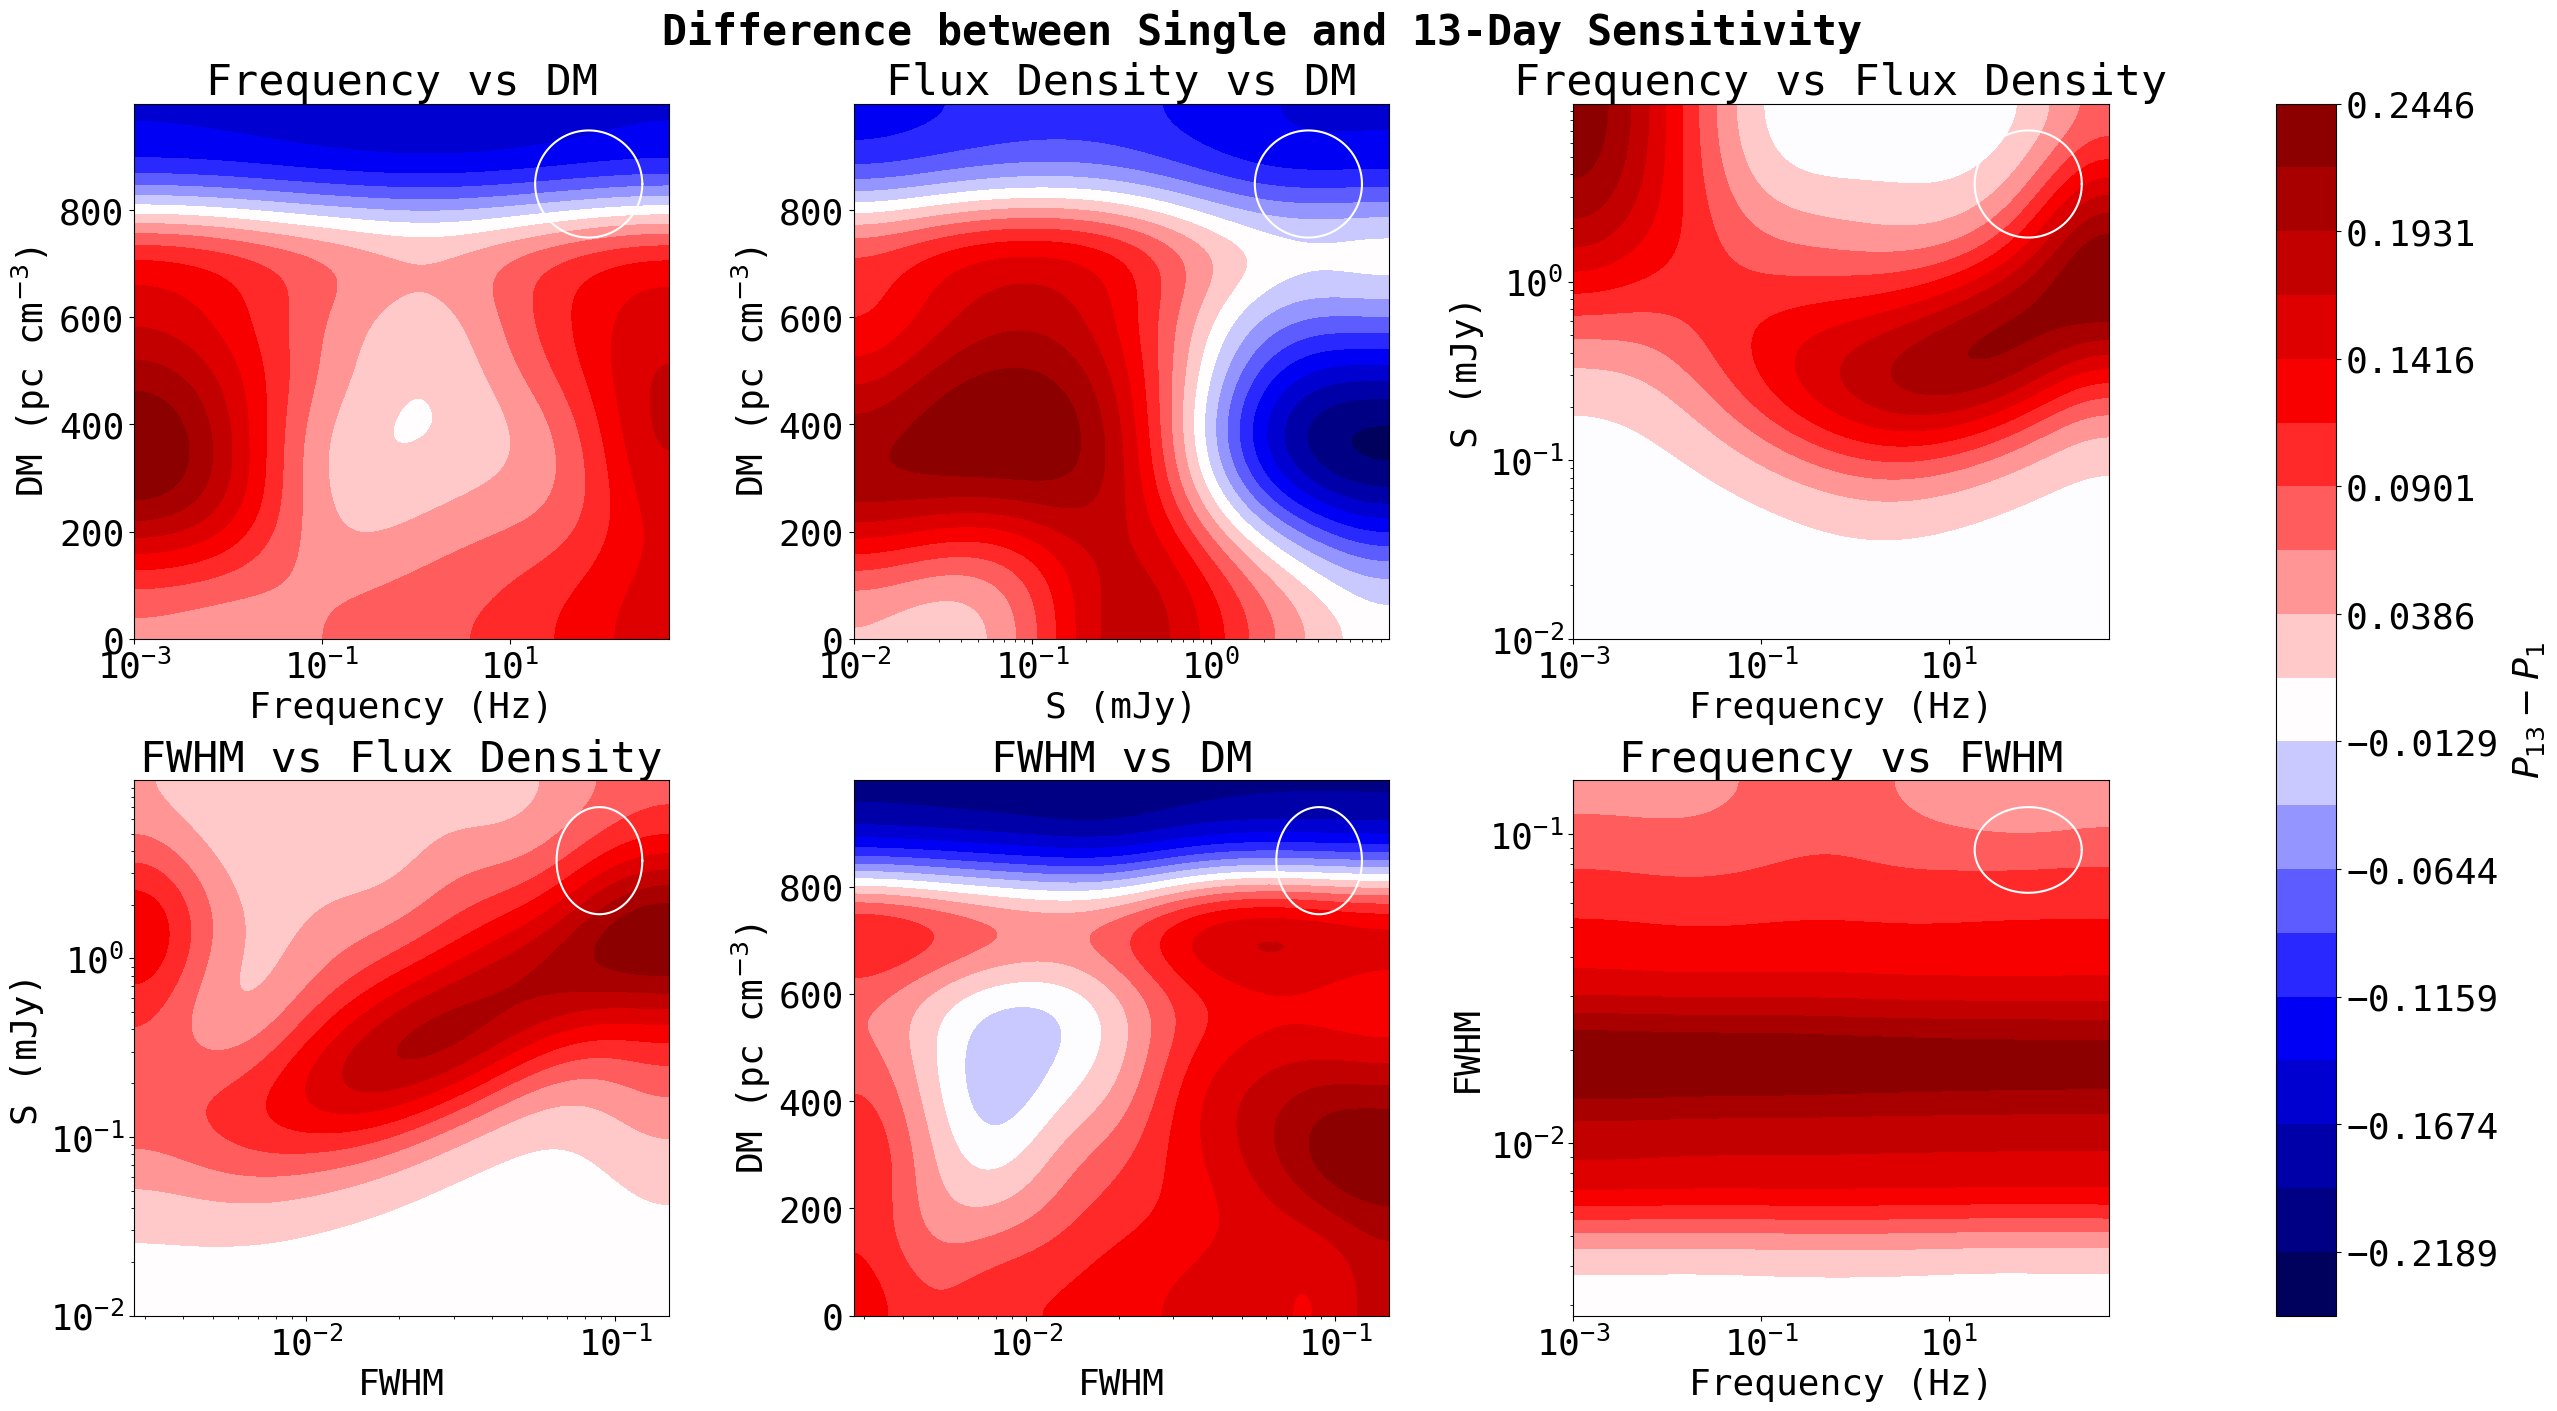

In [26]:
fig, ax = plt.subplots(2, 3, figsize=(26, 14), layout = 'constrained')
ax = ax.flatten()
#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_diff_smooth, 
                           levels=au.make_levels(dm_f_diff_smooth, diverging = True),
                           cmap='seismic')
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
#ax[0].set_xlim(1e-2, max(f_bins))
#ax[0].set_ylim(0, 700)
ax[0].set_box_aspect(1)
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_diff_smooth, 
                           levels=au.make_levels(dm_s_diff_smooth, diverging = True),
                            cmap='seismic')
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
#ax[1].set_xlim(1e-1, max(S_bins) - 1)
#ax[1].set_ylim(0, 700)
ax[1].set_box_aspect(1)
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = ax[2].contourf(f_bins[:-1], S_bins[:-1], s_f_diff_smooth, 
                           levels=au.make_levels(s_f_diff_smooth, diverging = True), 
                           cmap='seismic')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('S (mJy)')
ax[2].set_title('Frequency vs Flux Density')
ax[2].set_box_aspect(1)
#ax[2].set_xlim(1e-2, max(f_bins))
#ax[2].set_ylim(1e-1, max(S_bins) - 1)
au.add_ellipse(ax[2], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = ax[3].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_diff_smooth, 
                           levels=au.make_levels(s_fwhm_diff_smooth, diverging = True), 
                           cmap='seismic')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('FWHM vs Flux Density')
ax[3].set_box_aspect(1)
#ax[3].set_ylim(5e-2, max(S_bins) -1 )
au.add_ellipse(ax[3], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = ax[4].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_diff_smooth, 
                           levels=au.make_levels(dm_fwhm_diff_smooth, diverging = True), 
                           cmap='seismic')
ax[4].set_xscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[4].set_title('FWHM vs DM')
#ax[4].set_ylim(0, 700)
ax[4].set_xlim(fwhm_bins[0], fwhm_bins[-2])
ax[4].set_box_aspect(1)
au.add_ellipse(ax[4], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = ax[5].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_diff_smooth, 
                           levels=au.make_levels(fwhm_f_diff_smooth, diverging = True), 
                           cmap='seismic')
ax[5].set_xscale('log')
ax[5].set_yscale('log')
ax[5].set_xlabel('Frequency (Hz)')
ax[5].set_ylabel('FWHM')
ax[5].set_title('Frequency vs FWHM')
ax[5].set_box_aspect(1)
ax[5].set_ylim(fwhm_bins[0], fwhm_bins[-2])
#ax[5].set_xlim(1e-2, max(f_bins))
au.add_ellipse(ax[5], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

cbar = fig.colorbar(cf5, ax=ax, location='right', pad=0.08)
cbar.set_label(r'$P_{13} - P_1$', labelpad=10)

fig.suptitle('Difference between Single and 13-Day Sensitivity', 
             fontsize=30, fontweight='bold')
plt.show()